# RNN (4 units) + Monte-Carlo TPM + Big Φ (SIA) 

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import pyphi

# ---------------------------------------------------------------
# PyPhi configuration
# ---------------------------------------------------------------
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False

device = torch.device("cpu")

# ---------------------------------------------------------------
# PART 1 — Parity Dataset
# ---------------------------------------------------------------
def generate_parity_data(n_samples=2000):
    X = np.random.randint(0, 2, (n_samples, 2))
    y = np.sum(X, axis=1) % 2
    return X.astype(np.float32), y.astype(np.float32)

X, y = generate_parity_data(2000)
X_train, y_train = X[:1600], y[:1600]
X_test, y_test = X[1600:], y[1600:]

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=64,
    shuffle=True
)

# ---------------------------------------------------------------
# PART 2 — RNN Model (CHANGED)
# ---------------------------------------------------------------
input_size = 2
hidden_size = 4

class RNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            nonlinearity="tanh",
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h0=None):
        x = x.unsqueeze(1)              # (batch, time=1, input)
        _, h = self.rnn(x, h0)          # h: (1, batch, hidden)
        out = self.fc(h.squeeze(0))
        return torch.sigmoid(out), h

model = RNNRegressor().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ---------------------------------------------------------------
# PART 3 — Hidden State Space
# ---------------------------------------------------------------
n_nodes = hidden_size
states = list(itertools.product([0, 1], repeat=n_nodes))
num_states = len(states)

mc_inputs_per_state = 400
mc_bernoulli_samples = 4
rng = np.random.RandomState(42)

connectivity = np.ones((n_nodes, n_nodes), dtype=int)

def idx_to_state(idx):
    return np.array(list(np.binary_repr(idx, width=n_nodes))).astype(int)

# ---------------------------------------------------------------
# PART 4 — Compute TPM + Big Φ (SIA)
# ---------------------------------------------------------------
def compute_big_phi_and_tpm(model):
    tpm_counts = np.zeros((num_states, num_states))

    with torch.no_grad():
        for i, h_state in enumerate(states):
            h0 = torch.tensor(h_state, dtype=torch.float32).view(1,1,-1)
            for _ in range(mc_inputs_per_state):
                x = rng.randint(0,2,size=(input_size,)).astype(np.float32)
                x_tensor = torch.tensor(x).view(1,1,-1)

                _, h_next = model.rnn(x_tensor, h0)
                probs = torch.sigmoid(h_next).squeeze().numpy()

                for _ in range(mc_bernoulli_samples):
                    s = (rng.rand(n_nodes) < probs).astype(int)
                    j = int("".join(map(str,s)),2)
                    tpm_counts[i,j] += 1

    tpm = tpm_counts + 1e-8
    tpm /= tpm.sum(axis=1, keepdims=True)

    network = pyphi.Network(tpm, connectivity)

    phi_vals, sia_objects = [], []
    for i in range(num_states):
        st = idx_to_state(i)
        try:
            subsystem = pyphi.Subsystem(network, st, tuple(range(n_nodes)))
            sia = pyphi.compute.sia(subsystem)
            phi_vals.append(sia.phi)
            sia_objects.append(sia)
        except:
            phi_vals.append(0.0)
            sia_objects.append(None)

    best_idx = np.argmax(phi_vals)
    return phi_vals[best_idx], tpm, sia_objects[best_idx], network

# ---------------------------------------------------------------
# PART 5 — Accuracy
# ---------------------------------------------------------------
def compute_accuracy(model):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(X_test)
        y_true = torch.tensor(y_test)
        preds,_ = model(x)
        preds = (preds.squeeze() > 0.5).float()
        return (preds == y_true).float().mean().item()

# ---------------------------------------------------------------
# PART 6 — Training loop
# ---------------------------------------------------------------
EPOCHS = 10
phi_list, acc_list = [], []

print("\nTRAINING RNN + IIT ANALYSIS\n")

for ep in range(1, EPOCHS+1):
    model.train()
    for xb,yb in train_loader:
        optimizer.zero_grad()
        pred,_ = model(xb)
        loss = criterion(pred.squeeze(), yb)
        loss.backward()
        optimizer.step()

    acc = compute_accuracy(model)
    phi, tpm, best_sia, network = compute_big_phi_and_tpm(model)

    phi_list.append(phi)
    acc_list.append(acc)

    print(f"Epoch {ep}: Accuracy={acc:.3f} | Big Φ={phi:.6f}")

# ---------------------------------------------------------------
# PART 7 — Big Φ vs Epoch
# ---------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(range(1,EPOCHS+1), phi_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Big Φ (SIA)")
plt.title("RNN Big Φ vs Epoch")
plt.grid(True)
plt.show()

# ---------------------------------------------------------------
# PART 8 — Big Φ vs Accuracy
# ---------------------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(acc_list, phi_list, marker='o')
plt.xlabel("Accuracy")
plt.ylabel("Big Φ (SIA)")
plt.title("RNN Big Φ vs Accuracy")
plt.grid(True)
plt.show()

# ---------------------------------------------------------------
# PART 9 — MIP-Cut TPM Visualization
# ---------------------------------------------------------------
subsystem = pyphi.Subsystem(
    network,
    idx_to_state(np.argmax(phi_list)),
    tuple(range(n_nodes))
)

sia = pyphi.compute.sia(subsystem)
cut = sia.cut

cut_subsystem = subsystem.apply_cut(cut)
cut_tpm_sbn = cut_subsystem.tpm
cut_tpm = pyphi.convert.state_by_node2state_by_state(cut_tpm_sbn)

diff = tpm - cut_tpm

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.heatmap(tpm, cmap="viridis")
plt.title("Original TPM")

plt.subplot(1,3,2)
sns.heatmap(cut_tpm, cmap="viridis")
plt.title(f"MIP-Cut TPM (Φ={sia.phi:.2f})")

plt.subplot(1,3,3)
sns.heatmap(diff, cmap="coolwarm", center=0)
plt.title("TPM Difference")

plt.tight_layout()
plt.show()


# SAVING THE RESULT

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -------------------------------
# Create directories
# -------------------------------
os.makedirs("results1/data", exist_ok=True)
os.makedirs("results1/figures", exist_ok=True)

# -------------------------------
# Save numerical data
# -------------------------------
# Big Φ vs Epoch
df_phi_epoch = pd.DataFrame({
    "epoch": range(1, len(phi_list) + 1),
    "big_phi": phi_list
})
df_phi_epoch.to_csv("results1/data/phi_vs_epoch.csv", index=False)

# Big Φ vs Accuracy
df_phi_acc = pd.DataFrame({
    "accuracy": acc_list,
    "big_phi": phi_list
})
df_phi_acc.to_csv("results1/data/phi_vs_accuracy.csv", index=False)

# Save TPM matrices
np.save("results1/data/original_tpm.npy", tpm)
np.save("results1/data/mip_cut_tpm.npy", cut_tpm)
np.save("results1/data/tpm_difference.npy", diff)

# -------------------------------
# Save figures
# -------------------------------

# 1. Big Φ vs Epoch
plt.figure(figsize=(7,5))
plt.plot(range(1, len(phi_list)+1), phi_list, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Big Φ (SIA)")
plt.title("Big Φ vs Epoch")
plt.grid(True)
plt.tight_layout()
plt.savefig("results1/figures/phi_vs_epoch.png", dpi=300)
plt.close()

# 2. Big Φ vs Accuracy
plt.figure(figsize=(7,5))
plt.plot(acc_list, phi_list, marker='o')
plt.xlabel("Accuracy")
plt.ylabel("Big Φ (SIA)")
plt.title("Big Φ vs Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("results1/figures/phi_vs_accuracy.png", dpi=300)
plt.close()

# 3. Original TPM
plt.figure(figsize=(6,5))
sns.heatmap(tpm, cmap="viridis")
plt.title("Original TPM")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.savefig("results1/figures/original_tpm.png", dpi=300)
plt.close()

# 4. MIP-cut TPM
plt.figure(figsize=(6,5))
sns.heatmap(cut_tpm, cmap="viridis")
plt.title(f"MIP-Cut TPM (Φ={sia.phi:.3f})")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.savefig("results1/figures/mip_cut_tpm.png", dpi=300)
plt.close()

# 5. TPM Difference
plt.figure(figsize=(6,5))
sns.heatmap(diff, cmap="coolwarm", center=0)
plt.title("TPM Difference (Original − Cut)")
plt.xlabel("Next State")
plt.ylabel("Current State")
plt.tight_layout()
plt.savefig("results1/figures/tpm_difference.png", dpi=300)
plt.close()

print("All data and figures saved under ./results1/")


All data and figures saved under ./results1/


#  Comparison of PHI VS PHI STAR of BARETT AND SETH VS PHI STAR OF OZUMI(DECODING PERSPECTIVE)


TRAINING GRU (hidden_size=4)



Computing concepts:  73%|████████████████▊      | 11/15 [00:03<00:00,  4.08it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Evaluating Φ cuts:  93%|██████████████████████▎ | 13/14 [00:03<00:00,  7.21it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

...

Computing concepts:  73%|████████████████▊      | 11/15 [00:02<00:00,  7.42it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Evaluating Φ cuts:  93%|██████████████████████▎ | 13/14 [00:03<00:00,  8.01it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Epoch 10 | Acc=1.000 | Φ_IIT=0.010419 | Φ*_Barrett=0.008045 | Φ*_Decoder=0.901962 | Φ_Approx=0.026477

CORRELATIONS


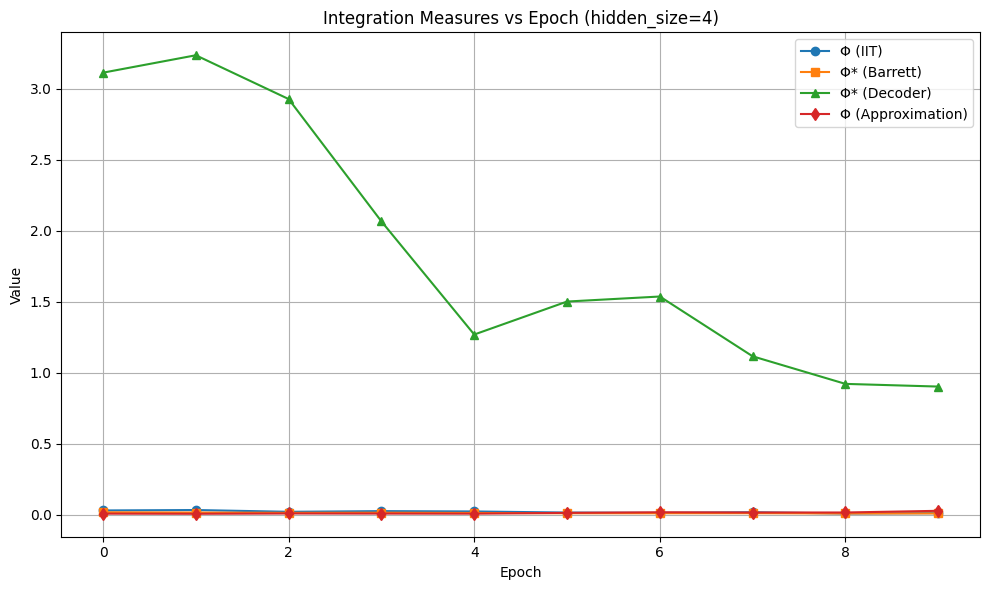


Pairwise correlations:
  Φ*_Barrett vs Φ_IIT: r=0.952, p=0.0000
  Φ*_Barrett vs Φ*_Decoder: r=0.889, p=0.0006
  Φ*_Barrett vs Φ_Approx: r=-0.782, p=0.0075
  Φ*_Decoder vs Φ_IIT: r=0.826, p=0.0032
  Φ*_Decoder vs Φ_Approx: r=-0.698, p=0.0248
  Φ_Approx vs Φ_IIT: r=-0.790, p=0.0066


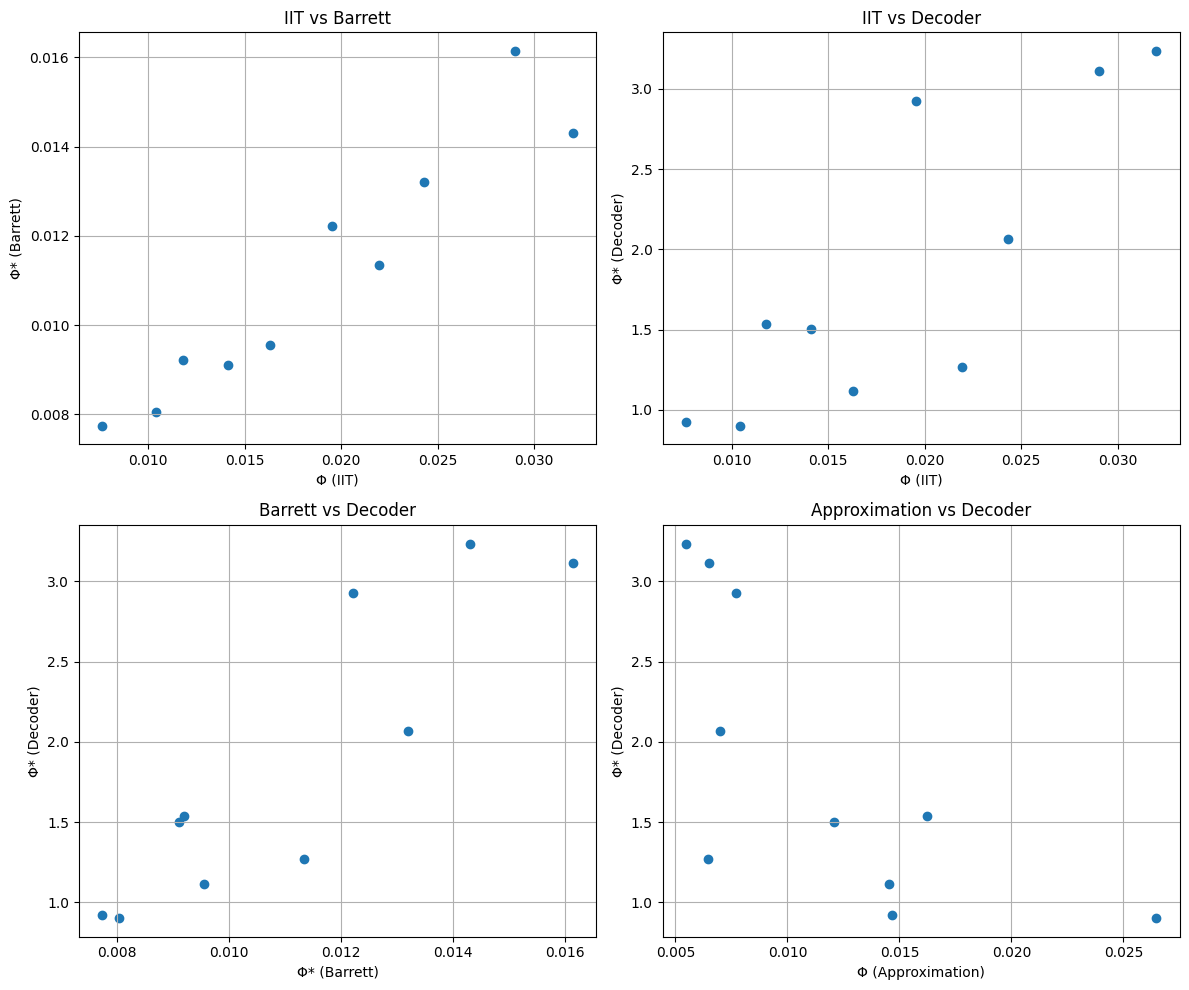

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import itertools
import matplotlib.pyplot as plt
import pyphi
from itertools import combinations
from scipy.stats import pearsonr

# ---------------------------------------------------------------
# PyPhi config
# ---------------------------------------------------------------
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False

device = torch.device("cpu")

# ---------------------------------------------------------------
# PART 1 — Parity Dataset
# ---------------------------------------------------------------
def generate_parity_data(n_samples=2000):
    X = np.random.randint(0, 2, (n_samples, 2))
    y = np.sum(X, axis=1) % 2
    return X.astype(np.float32), y.astype(np.float32)

X, y = generate_parity_data()
X_train, y_train = X[:1600], y[:1600]
X_test, y_test = X[1600:], y[1600:]

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
    batch_size=64,
    shuffle=True
)

# ---------------------------------------------------------------
# PART 2 — RNN Model (configurable hidden units)
# ---------------------------------------------------------------

input_size = 2
hidden_size = 4

class RNNRegressor(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            nonlinearity="tanh",
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h0=None):
        x = x.unsqueeze(1)              # (batch, time=1, input)
        _, h = self.rnn(x, h0)          # h: (1, batch, hidden)
        out = self.fc(h.squeeze(0))
        return torch.sigmoid(out), h

model = RNNRegressor().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ---------------------------------------------------------------
# PART 3 — State space & Monte-Carlo params
# ---------------------------------------------------------------
n_nodes = hidden_size
states = list(itertools.product([0,1], repeat=n_nodes))
num_states = len(states)

mc_inputs_per_state = 400
mc_bernoulli_samples = 4
rng = np.random.RandomState(42)

connectivity = np.ones((n_nodes, n_nodes), dtype=int)

def idx_to_state(idx):
    return np.array(list(np.binary_repr(idx, width=n_nodes))).astype(int)

# ---------------------------------------------------------------
# PART 4 — Compute Big Φ (IIT / SIA) - Only for small models
# ---------------------------------------------------------------
def compute_big_phi_and_tpm(model):
    """Only feasible for hidden_size <= 6"""
    if hidden_size > 6:
        print("⚠️  Skipping full IIT Φ computation (too large)")
        return None, None
    
    tpm_counts = np.zeros((num_states, num_states))

    with torch.no_grad():
        for i, h_state in enumerate(states):
            h0 = torch.tensor(h_state, dtype=torch.float32).view(1,1,-1)

            for _ in range(mc_inputs_per_state):
                x = rng.randint(0,2,size=(input_size,)).astype(np.float32)
                x_tensor = torch.tensor(x).view(1,1,-1)

                _, h_next = model.rnn(x_tensor, h0)
                probs = torch.sigmoid(h_next).squeeze().numpy()

                for _ in range(mc_bernoulli_samples):
                    s = (rng.rand(n_nodes) < probs).astype(int)
                    j = int("".join(map(str,s)),2)
                    tpm_counts[i,j] += 1

    tpm = tpm_counts + 1e-8
    tpm /= tpm.sum(axis=1, keepdims=True)

    network = pyphi.Network(tpm, connectivity)

    phi_vals = []
    for i in range(num_states):
        try:
            subsystem = pyphi.Subsystem(network, idx_to_state(i), tuple(range(n_nodes)))
            sia = pyphi.compute.sia(subsystem)
            phi_vals.append(sia.phi)
        except:
            phi_vals.append(0.0)

    return max(phi_vals), tpm

# ---------------------------------------------------------------
# PART 5 — Φ* (Barrett & Seth) - Original version
# ---------------------------------------------------------------
def mutual_information(joint):
    px = joint.sum(axis=1, keepdims=True)
    py = joint.sum(axis=0, keepdims=True)
    eps = 1e-12
    joint += eps; px += eps; py += eps
    return np.sum(joint * np.log2(joint / (px @ py)))

def compute_phi_star_barrett(tpm, n_nodes):
    """Original Barrett & Seth Φ* using MI decomposition"""
    if tpm is None:
        return None
    
    p_xt = np.ones(tpm.shape[0]) / tpm.shape[0]
    joint = p_xt[:,None] * tpm
    I_whole = mutual_information(joint)

    states = list(itertools.product([0,1], repeat=n_nodes))
    min_phi_star = np.inf
    nodes = list(range(n_nodes))

    for k in range(1, n_nodes//2 + 1):
        for part in combinations(nodes, k):
            comp = tuple(set(nodes) - set(part))

            def project(subset):
                mapping = {}
                for i,s in enumerate(states):
                    key = tuple(s[j] for j in subset)
                    mapping.setdefault(key, []).append(i)
                return mapping

            I_cut = 0.0
            for group in [project(part), project(comp)]:
                joint_sub = np.zeros((len(group), len(group)))
                keys = list(group.keys())
                for i,ki in enumerate(keys):
                    for j,kj in enumerate(keys):
                        for si in group[ki]:
                            for sj in group[kj]:
                                joint_sub[i,j] += joint[si,sj]
                I_cut += mutual_information(joint_sub)

            min_phi_star = min(min_phi_star, I_whole - I_cut)

    return max(min_phi_star, 0.0)

# ---------------------------------------------------------------
# PART 6 — Decoder-based Φ* with Gaussian Approximation (SCALES!)
# ---------------------------------------------------------------
def collect_hidden_states(model, n_samples=2000):
    """Collect hidden state trajectories from the GRU"""
    states_list = []
    
    with torch.no_grad():
        h = None
        for _ in range(n_samples):
            x = rng.randint(0, 2, size=(1, input_size)).astype(np.float32)
            x_tensor = torch.tensor(x).view(1, 1, -1)
            
            _, h = model.rnn(x_tensor, h)
            states_list.append(h.squeeze().numpy())
    
    return np.array(states_list)

def compute_phi_star_decoder_gaussian(model, n_samples=2000):
    """
    Decoder-based Φ* using Gaussian approximation.
    Measures information loss when splitting the system.
    
    This scales to large models! O(n³) instead of O(2^n)
    """
    # Collect state trajectories
    states = collect_hidden_states(model, n_samples)
    n_nodes = states.shape[1]
    
    # Compute covariance matrices for Gaussian approximation
    # States at time t and t-1
    X_t = states[1:]  # Current states
    X_tm1 = states[:-1]  # Previous states
    
    # Center the data
    X_t_mean = X_t.mean(axis=0)
    X_tm1_mean = X_tm1.mean(axis=0)
    X_t_centered = X_t - X_t_mean
    X_tm1_centered = X_tm1 - X_tm1_mean
    
    # Compute covariances
    Cov_t = np.cov(X_t_centered.T) + 1e-6 * np.eye(n_nodes)
    Cov_tm1 = np.cov(X_tm1_centered.T) + 1e-6 * np.eye(n_nodes)
    Cov_joint = np.cov(np.hstack([X_tm1_centered, X_t_centered]).T)
    
    # Total mutual information I(X_t; X_{t-1})
    # For Gaussian: MI = 0.5 * log(|Cov_t| * |Cov_tm1| / |Cov_joint|)
    sign_t, logdet_t = np.linalg.slogdet(Cov_t)
    sign_tm1, logdet_tm1 = np.linalg.slogdet(Cov_tm1)
    sign_joint, logdet_joint = np.linalg.slogdet(Cov_joint)
    
    I_whole = 0.5 * (logdet_t + logdet_tm1 - logdet_joint) / np.log(2)  # Convert to bits
    
    # Find minimum information partition (MIP)
    nodes = list(range(n_nodes))
    min_phi_decoder = np.inf
    
    for k in range(1, n_nodes // 2 + 1):
        for partition in combinations(nodes, k):
            part_A = list(partition)
            part_B = list(set(nodes) - set(partition))
            
            # Compute MI for each partition independently
            I_cut = 0.0
            
            for part in [part_A, part_B]:
                if len(part) == 0:
                    continue
                
                # Extract submatrices for this partition
                Cov_t_sub = Cov_t[np.ix_(part, part)]
                Cov_tm1_sub = Cov_tm1[np.ix_(part, part)]
                
                # Joint covariance for this partition
                part_indices = part + [p + n_nodes for p in part]
                Cov_joint_sub = Cov_joint[np.ix_(part_indices, part_indices)]
                
                # MI for this partition
                sign_t_sub, logdet_t_sub = np.linalg.slogdet(Cov_t_sub)
                sign_tm1_sub, logdet_tm1_sub = np.linalg.slogdet(Cov_tm1_sub)
                sign_joint_sub, logdet_joint_sub = np.linalg.slogdet(Cov_joint_sub)
                
                I_part = 0.5 * (logdet_t_sub + logdet_tm1_sub - logdet_joint_sub) / np.log(2)
                I_cut += I_part
            
            # Φ for this partition
            phi_partition = I_whole - I_cut
            min_phi_decoder = min(min_phi_decoder, phi_partition)
    
    return max(min_phi_decoder, 0.0)

# ---------------------------------------------------------------
# PART 7 — Φ Approximation for Large Models (Tononi et al. 2016)
# ---------------------------------------------------------------
def compute_phi_approximation(model, n_samples=2000):
    """
    Fast Φ approximation based on Tononi et al. (2016)
    Uses singular value decomposition of the interaction matrix.
    
    Scales to large models! O(n³)
    """
    # Collect state trajectories
    states = collect_hidden_states(model, n_samples)
    n_nodes = states.shape[1]
    
    X_t = states[1:]
    X_tm1 = states[:-1]
    
    # Center data
    X_t_centered = X_t - X_t.mean(axis=0)
    X_tm1_centered = X_tm1 - X_tm1.mean(axis=0)
    
    # Estimate interaction matrix via linear regression
    # X_t ≈ W @ X_{t-1}
    W = np.linalg.lstsq(X_tm1_centered, X_t_centered, rcond=None)[0].T
    
    # Compute covariance matrices
    Cov_t = np.cov(X_t_centered.T) + 1e-6 * np.eye(n_nodes)
    Cov_tm1 = np.cov(X_tm1_centered.T) + 1e-6 * np.eye(n_nodes)
    
    # SVD-based approximation
    U, S, Vt = np.linalg.svd(W)
    
    # Φ approximation using effective information
    # Sum of squared singular values weighted by variance
    var_tm1 = np.diag(Cov_tm1)
    phi_approx = 0.0
    
    for i in range(min(n_nodes, len(S))):
        # Effective information carried by each singular vector
        ei = S[i]**2 * var_tm1[i] if i < len(var_tm1) else S[i]**2
        phi_approx += ei
    
    # Normalize by system size for comparability
    phi_approx = phi_approx / n_nodes
    
    return phi_approx

# ---------------------------------------------------------------
# PART 8 — Accuracy
# ---------------------------------------------------------------
def compute_accuracy(model):
    with torch.no_grad():
        preds,_ = model(torch.tensor(X_test))
        preds = (preds.squeeze() > 0.5).float()
        return (preds == torch.tensor(y_test)).float().mean().item()

# ---------------------------------------------------------------
# PART 9 — Training + All Φ measures
# ---------------------------------------------------------------
EPOCHS = 10
phi_list, phi_star_barrett_list, phi_star_decoder_list, phi_approx_list, acc_list = [], [], [], [], []

print(f"\n{'='*60}")
print(f"TRAINING GRU (hidden_size={hidden_size})")
print(f"{'='*60}\n")

for ep in range(1, EPOCHS+1):
    model.train()
    for xb,yb in train_loader:
        optimizer.zero_grad()
        pred,_ = model(xb)
        loss = criterion(pred.squeeze(), yb)
        loss.backward()
        optimizer.step()

    acc = compute_accuracy(model)
    
    # Full IIT Φ (only for small models)
    if hidden_size <= 6:
        phi, tpm = compute_big_phi_and_tpm(model)
        phi_star_barrett = compute_phi_star_barrett(tpm, n_nodes)
    else:
        phi = None
        phi_star_barrett = None
    
    # Scalable measures (work for any size!)
    phi_star_decoder = compute_phi_star_decoder_gaussian(model)
    phi_approx = compute_phi_approximation(model)
    
    phi_list.append(phi)
    phi_star_barrett_list.append(phi_star_barrett)
    phi_star_decoder_list.append(phi_star_decoder)
    phi_approx_list.append(phi_approx)
    acc_list.append(acc)

    if phi is not None:
        print(f"Epoch {ep} | Acc={acc:.3f} | Φ_IIT={phi:.6f} | Φ*_Barrett={phi_star_barrett:.6f} | Φ*_Decoder={phi_star_decoder:.6f} | Φ_Approx={phi_approx:.6f}")
    else:
        print(f"Epoch {ep} | Acc={acc:.3f} | Φ*_Decoder={phi_star_decoder:.6f} | Φ_Approx={phi_approx:.6f}")

# ---------------------------------------------------------------
# PART 10 — Plots & Correlations
# ---------------------------------------------------------------
print(f"\n{'='*60}")
print("CORRELATIONS")
print(f"{'='*60}")

if hidden_size <= 6:
    # Plot all measures
    plt.figure(figsize=(10,6))
    plt.plot(phi_list, label="Φ (IIT)", marker='o')
    plt.plot(phi_star_barrett_list, label="Φ* (Barrett)", marker='s')
    plt.plot(phi_star_decoder_list, label="Φ* (Decoder)", marker='^')
    plt.plot(phi_approx_list, label="Φ (Approximation)", marker='d')
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(f"Integration Measures vs Epoch (hidden_size={hidden_size})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Correlation matrix
    measures = {
        'Φ_IIT': phi_list,
        'Φ*_Barrett': phi_star_barrett_list,
        'Φ*_Decoder': phi_star_decoder_list,
        'Φ_Approx': phi_approx_list
    }
    
    print("\nPairwise correlations:")
    for m1 in measures:
        for m2 in measures:
            if m1 < m2:
                r, p = pearsonr(measures[m1], measures[m2])
                print(f"  {m1} vs {m2}: r={r:.3f}, p={p:.4f}")
    
    # Scatter plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    axes[0,0].scatter(phi_list, phi_star_barrett_list)
    axes[0,0].set_xlabel("Φ (IIT)")
    axes[0,0].set_ylabel("Φ* (Barrett)")
    axes[0,0].set_title("IIT vs Barrett")
    axes[0,0].grid(True)
    
    axes[0,1].scatter(phi_list, phi_star_decoder_list)
    axes[0,1].set_xlabel("Φ (IIT)")
    axes[0,1].set_ylabel("Φ* (Decoder)")
    axes[0,1].set_title("IIT vs Decoder")
    axes[0,1].grid(True)
    
    axes[1,0].scatter(phi_star_barrett_list, phi_star_decoder_list)
    axes[1,0].set_xlabel("Φ* (Barrett)")
    axes[1,0].set_ylabel("Φ* (Decoder)")
    axes[1,0].set_title("Barrett vs Decoder")
    axes[1,0].grid(True)
    
    axes[1,1].scatter(phi_approx_list, phi_star_decoder_list)
    axes[1,1].set_xlabel("Φ (Approximation)")
    axes[1,1].set_ylabel("Φ* (Decoder)")
    axes[1,1].set_title("Approximation vs Decoder")
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
else:
    # For large models, only plot scalable measures
    plt.figure(figsize=(8,5))
    plt.plot(phi_star_decoder_list, label="Φ* (Decoder)", marker='^')
    plt.plot(phi_approx_list, label="Φ (Approximation)", marker='d')
    plt.xlabel("Epoch")
    plt.ylabel("Value")
    plt.title(f"Scalable Integration Measures (hidden_size={hidden_size})")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    r, p = pearsonr(phi_star_decoder_list, phi_approx_list)
    print(f"\nΦ_Approx vs Φ*_Decoder: r={r:.3f}, p={p:.4f}")



In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------- Save results --------------------
results = {
    'Epoch': list(range(1, EPOCHS+1)),
    'Accuracy': acc_list,
    'Phi_IIT': phi_list,
    'Phi_Star_Barrett': phi_star_barrett_list,
    'Phi_Star_Decoder': phi_star_decoder_list,
    'Phi_Approx': phi_approx_list
}

df = pd.DataFrame(results)
df.to_csv("gru_phi_results.csv", index=False)
print("✅ Results saved to 'gru_phi_results.csv'")

# -------------------- Save plots --------------------
# Plot integration measures vs epoch
plt.figure(figsize=(10,6))
if hidden_size <= 6:
    plt.plot(phi_list, label="Φ (IIT)", marker='o')
    plt.plot(phi_star_barrett_list, label="Φ* (Barrett)", marker='s')
plt.plot(phi_star_decoder_list, label="Φ* (Decoder)", marker='^')
plt.plot(phi_approx_list, label="Φ (Approximation)", marker='d')
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title(f"Integration Measures vs Epoch (hidden_size={hidden_size})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("phi_measures_vs_epoch.png")
plt.close()
print("✅ Plot saved as 'phi_measures_vs_epoch.png'")

# Scatter plot matrix (optional)
import seaborn as sns

# Prepare DataFrame for scatter plots
scatter_df = df.copy()
# Remove None columns (for large models)
scatter_df = scatter_df.dropna(axis=1, how='all')

sns.pairplot(scatter_df.drop(columns=['Epoch']))
plt.savefig("phi_scatter_matrix.png")
plt.close()
print("✅ Scatter matrix saved as 'phi_scatter_matrix.png'")


✅ Results saved to 'gru_phi_results.csv'
✅ Plot saved as 'phi_measures_vs_epoch.png'
✅ Scatter matrix saved as 'phi_scatter_matrix.png'


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import font_manager

# -------------------------------
# Load CSV files
# -------------------------------
df_phi_epoch = pd.read_csv("./results1/data/phi_vs_epoch.csv")
df_phi_accuracy = pd.read_csv("./results1/data/phi_vs_accuracy.csv")

SAVE_DIR = "./PNG Files(TimesNewRoman)"
os.makedirs(SAVE_DIR, exist_ok=True)

# -------------------------------
# Merge all data on 'epoch'
# -------------------------------
df_merged = pd.merge(
    df_phi_epoch,       # epoch + big_phi
    df_phi_accuracy,    # accuracy + big_phi
    on="big_phi",
    how="inner"
)

epochs = df_merged["epoch"]
accuracy = df_merged["accuracy"]
phi = df_merged["big_phi"]

print(df_merged.head())



   epoch   big_phi  accuracy
0      1  0.026972    0.7725
1      2  0.032201    0.4975
2      3  0.019094    0.7725
3      4  0.023561    0.7725
4      5  0.015107    0.7725


In [2]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]  # or any installed font

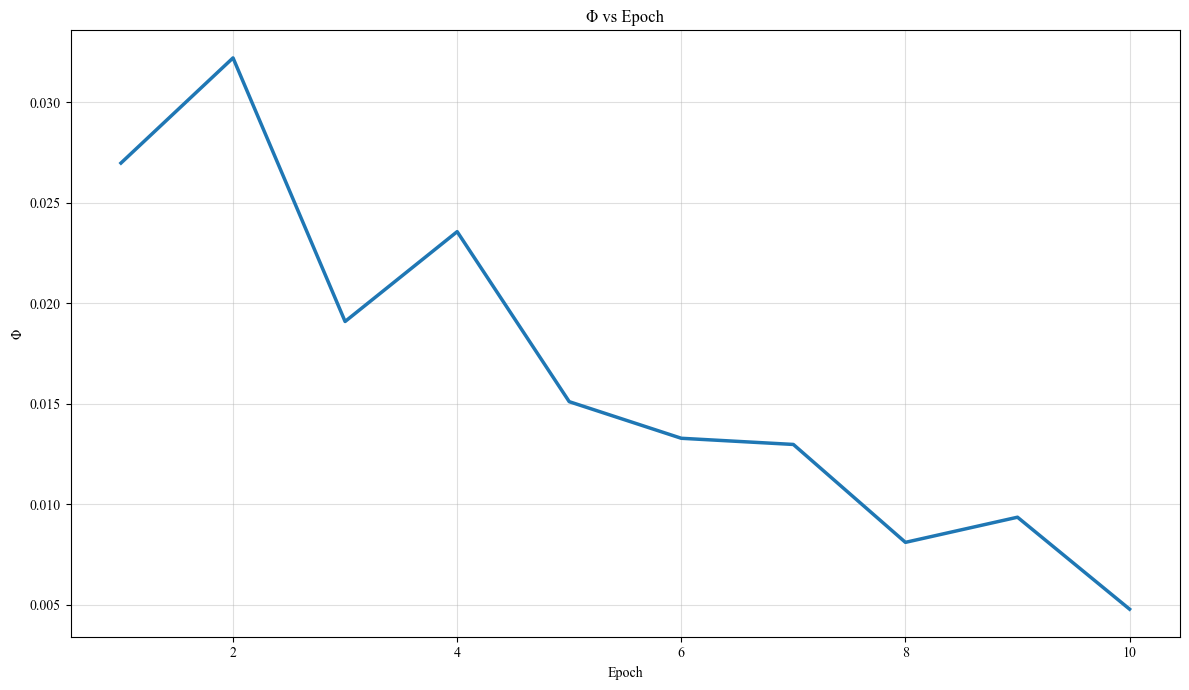

In [3]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, phi, linewidth=2.5)
plt.xlabel("Epoch")
plt.ylabel("Φ")
plt.title("Φ vs Epoch")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/phi_vs_epoch.png", dpi=300)
plt.show()


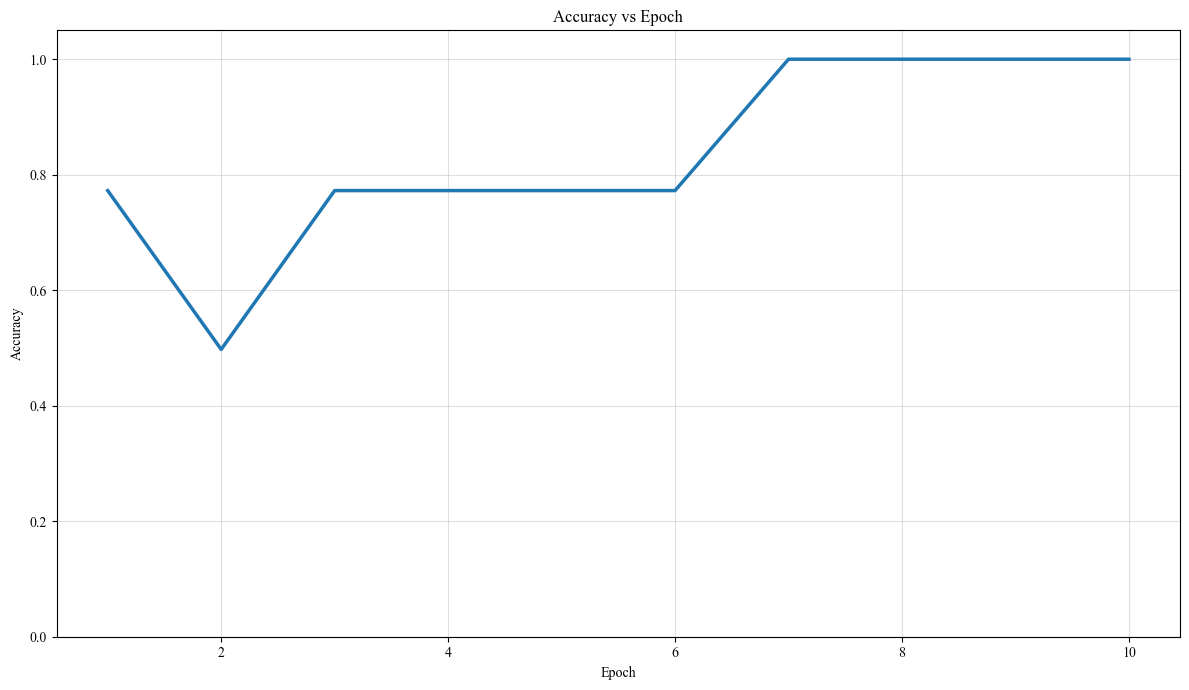

In [7]:
plt.figure(figsize=(12, 7))
plt.plot(epochs, accuracy, linewidth=2.5)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/accuracy_vs_epoch.png", dpi=300)
plt.show()


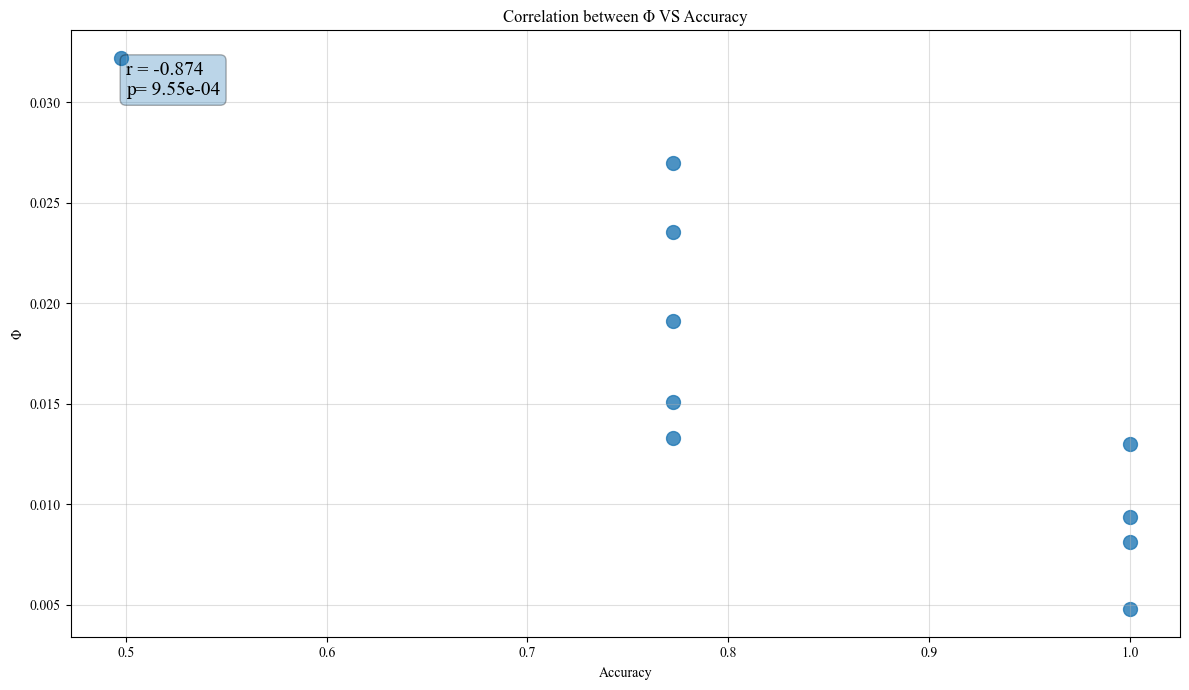

Pearson r = -0.874, p = 9.55e-04


In [4]:
from scipy.stats import pearsonr

r, p = pearsonr(accuracy, phi)

plt.figure(figsize=(12, 7))
plt.scatter(accuracy, phi, s=100, alpha=0.8)
plt.xlabel("Accuracy")
plt.ylabel("Φ")
plt.title("Correlation between Φ VS Accuracy")

plt.text(
    0.05, 0.95,
    f"r = {r:.3f}\np= {p:.2e}",
    transform=plt.gca().transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round", alpha=0.3)
)

plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/phi_accuracy_correlation.png", dpi=300)
plt.show()

print(f"Pearson r = {r:.3f}, p = {p:.2e}")


TPM shape: (16, 16)


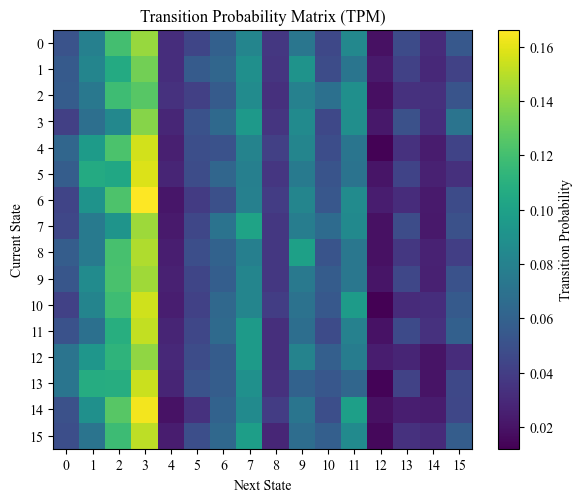

In [10]:
import numpy as np

# Load TPM (assuming .npy)
TPM = np.load("./results1/data/original_tpm.npy")  # replace with your file path
print("TPM shape:", TPM.shape)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(TPM, cmap="viridis", interpolation="nearest")  # 'viridis' or 'hot' or 'coolwarm'
plt.colorbar(label="Transition Probability")
plt.title("Transition Probability Matrix (TPM)")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.xticks(range(TPM.shape[1]))
plt.yticks(range(TPM.shape[0]))

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/original_tpm.png", dpi=300)
plt.show()


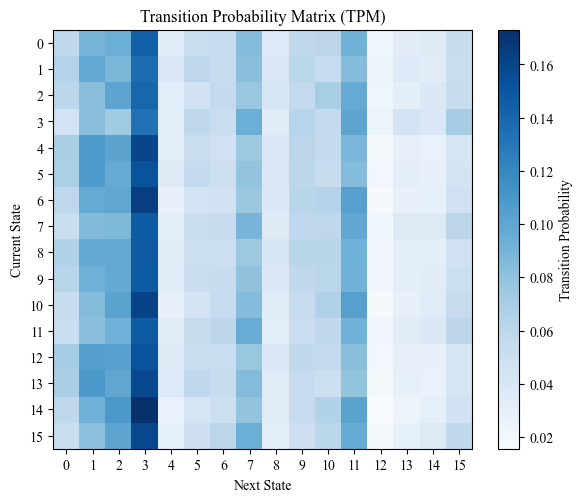

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Load TPM (assuming .npy)
TPM = np.load("./results1/data/mip_cut_tpm.npy") 

plt.figure(figsize=(6, 5))
plt.imshow(TPM, cmap="Blues", interpolation="nearest")  # 'viridis' or 'hot' or 'coolwarm'
plt.colorbar(label="Transition Probability")
plt.title("Transition Probability Matrix (TPM)")
plt.xlabel("Next State")
plt.ylabel("Current State")

plt.xticks(range(TPM.shape[1]))
plt.yticks(range(TPM.shape[0]))

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/mip_cut_tpm.png", dpi=300)
plt.show()